In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from pathlib import Path

from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.graphics.tsaplots import plot_acf

In [2]:
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "Feature_Pipeline" else CWD
RAW_DIR = PROJECT_ROOT / "Data" / "Raw"
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
day1 = pd.read_csv(PROCESSED_DIR / "Day_One_AQI.csv", index_col="time", parse_dates=True)

In [4]:
day1.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_boundary_layer_height,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level,Day_1_Future_AQI
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,818.333333,24.866667,0.037500,69.833333,33.450000,220.291667,15605.187500,0.225000,3.150000,79.458333
2023-08-05 00:00:00+05:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,900.416667,24.479167,0.029167,81.625000,45.562500,175.958333,18252.291667,0.266667,3.462500,78.833333
2023-08-06 00:00:00+05:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,916.458333,24.266667,0.070833,75.000000,49.770833,171.375000,27933.375000,-0.387500,3.754167,78.875000
2023-08-07 00:00:00+05:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,805.416667,24.512500,0.091667,68.541667,44.275000,172.000000,30741.333333,-0.200000,3.775000,78.791667
2023-08-08 00:00:00+05:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,798.750000,24.487500,0.033333,72.916667,43.120833,220.875000,23936.687500,0.304167,3.483333,73.416667


In [5]:
day1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1092 entries, 2023-08-04 00:00:00+05:00 to 2026-07-30 00:00:00+05:00
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature_2m             1092 non-null   float64
 1   wind_speed_10m             1092 non-null   float64
 2   relative_humidity_2m       1092 non-null   float64
 3   surface_pressure           1092 non-null   float64
 4   boundary_layer_height      911 non-null    float64
 5   dew_point_2m               1092 non-null   float64
 6   precipitation              1092 non-null   float64
 7   cloud_cover                1092 non-null   float64
 8   wind_direction_10m         1092 non-null   float64
 9   wind_gusts_10m             1092 non-null   float64
 10  shortwave_radiation        1092 non-null   float64
 11  pm10                       1092 non-null   float64
 12  pm2_5                      1092 non-null   float64
 13  

# Summary Statistics

In [6]:
day1.describe()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_boundary_layer_height,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level,Day_1_Future_AQI
count,1092.000000,1092.000000,1092.000000,1092.000000,911.000000,1092.000000,1092.000000,1092.000000,1092.000000,1092.000000,...,911.000000,1092.000000,1092.000000,1092.000000,1092.000000,1092.000000,911.000000,1.092000e+03,1092.000000,1092.000000
mean,26.611622,13.436359,65.205052,1007.853339,540.192238,18.480743,0.026366,33.089286,216.947840,27.184974,...,539.832514,18.481620,0.026332,33.122253,27.178079,222.550977,7851.342863,-3.434066e-04,8.130880,88.270261
std,3.871909,5.515391,16.208220,6.696093,189.256494,7.609398,0.152568,31.784101,70.592449,8.129861,...,189.163534,7.610239,0.152569,31.820393,8.129016,47.095717,5308.311775,1.899850e-01,5.000632,22.334944
min,13.616667,4.708333,13.833333,991.895833,155.000000,-7.237500,0.000000,0.000000,24.416667,12.466667,...,155.000000,-7.237500,0.000000,0.000000,12.466667,62.875000,692.791667,-6.458333e-01,1.383333,48.333333
25%,23.478125,9.303125,54.489583,1002.558333,389.895833,12.809375,0.000000,2.989583,186.552083,20.333333,...,389.895833,12.809375,0.000000,2.989583,20.333333,184.083333,3702.541667,-1.250000e-01,4.607292,72.229167
50%,27.820833,12.327083,71.729167,1007.989583,533.958333,21.764583,0.000000,22.833333,246.812500,26.247917,...,533.958333,21.764583,0.000000,22.833333,26.195833,218.937500,6642.395833,-2.368476e-15,5.902083,82.666667
75%,29.714583,16.689583,77.177083,1013.692708,683.125000,24.558333,0.000000,58.385417,262.843750,32.944792,...,682.708333,24.558333,0.000000,58.593750,32.944792,257.510417,10710.406250,1.208333e-01,11.060417,98.645833
max,34.262500,34.637500,92.250000,1021.250000,1102.500000,27.416667,2.683333,100.000000,320.583333,52.779167,...,1102.500000,27.416667,2.683333,100.000000,52.779167,323.083333,37639.291667,7.000000e-01,29.562500,180.083333


# Simple Plot

<Axes: xlabel='time'>

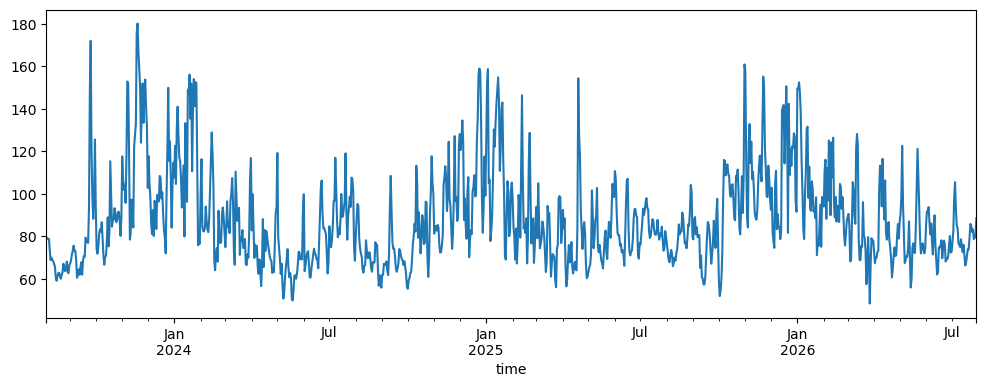

In [7]:
day1["Day_1_Future_AQI"].plot(figsize=(12,4))

<Axes: xlabel='time'>

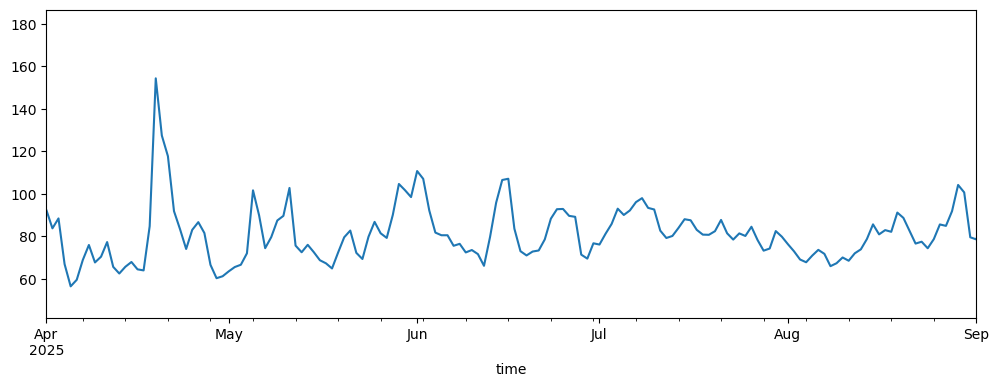

In [8]:
day1["Day_1_Future_AQI"].plot(xlim = ['2025-04-01','2025-09-01'], figsize=(12,4))

# Note:
1. The AQI is low from March to September, and November to February high.
2. There is a seasonal pattern.
3. The highest AQI is 180 and lowest is 48.

# AQI Category Understanding

In [9]:
day1["us_aqi"].max()

180.08333333333334

In [10]:
day1["us_aqi"].min()

48.333333333333336

In [11]:
labels = ["Good", "Moderate", "Unhealthy for Sensitive", "Unhealthy", "Very Unhealthy", "Hazardous"]
bins = [0, 50, 100, 150, 200, 300, 500]

day1['AQI-Category'] = pd.cut(day1["us_aqi"],bins,labels=labels,include_lowest=True)

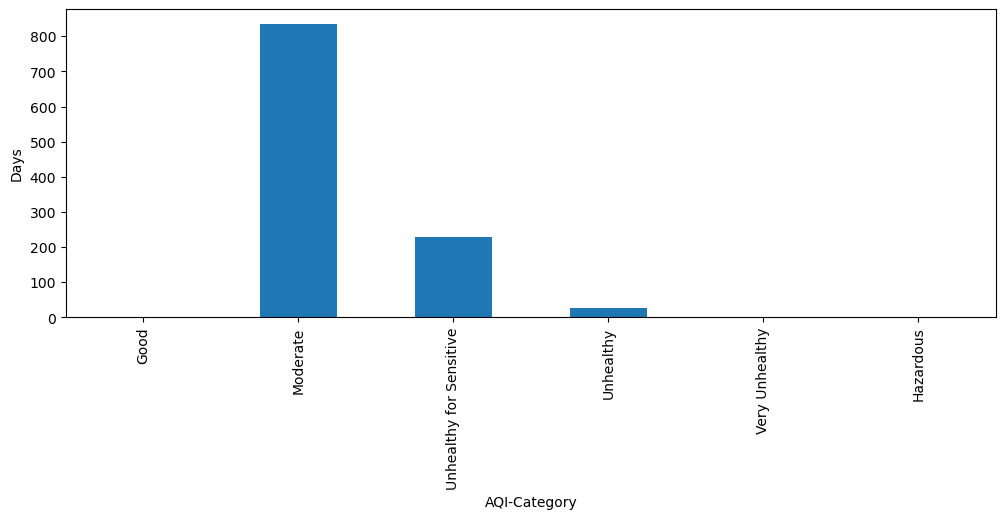

In [12]:
day1['AQI-Category'].value_counts().sort_index().plot(kind='bar', figsize=(12,4))
plt.ylabel('Days')
plt.show()

In [13]:
day1.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level,Day_1_Future_AQI,AQI-Category
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,24.866667,0.037500,69.833333,33.450000,220.291667,15605.187500,0.225000,3.150000,79.458333,Moderate
2023-08-05 00:00:00+05:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,24.479167,0.029167,81.625000,45.562500,175.958333,18252.291667,0.266667,3.462500,78.833333,Moderate
2023-08-06 00:00:00+05:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,24.266667,0.070833,75.000000,49.770833,171.375000,27933.375000,-0.387500,3.754167,78.875000,Moderate
2023-08-07 00:00:00+05:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,24.512500,0.091667,68.541667,44.275000,172.000000,30741.333333,-0.200000,3.775000,78.791667,Moderate
2023-08-08 00:00:00+05:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,24.487500,0.033333,72.916667,43.120833,220.875000,23936.687500,0.304167,3.483333,73.416667,Moderate


In [14]:
day1['AQI-Category'].value_counts()

AQI-Category
Moderate                   835
Unhealthy for Sensitive    228
Unhealthy                   27
Good                         2
Very Unhealthy               0
Hazardous                    0
Name: count, dtype: int64

In [15]:
day1['AQI-Category'].value_counts()/len(day1["us_aqi"])*100

AQI-Category
Moderate                   76.465201
Unhealthy for Sensitive    20.879121
Unhealthy                   2.472527
Good                        0.183150
Very Unhealthy              0.000000
Hazardous                   0.000000
Name: count, dtype: float64

# Note:
1. Moderate(51-100): 76.5% of hours have a moderate AQI level. This is Karachi's typical air quality.
2. Unhealthy for Sensitive(101-150): Unhealthy for Sensitive is about 20.88%, meaning sensitive groups face air quality concerns roughly one-fifth of the time.
3. Unhealthy(151-200): Unhealthy is about 2.47%, these are short pollution events.
4. Good (0-50): Good is about 2 days (0.18%) so the clean air is extremely rare.
5. No record for Very Unhealthy and Hazardous.

# Correlation Understanding

<Axes: >

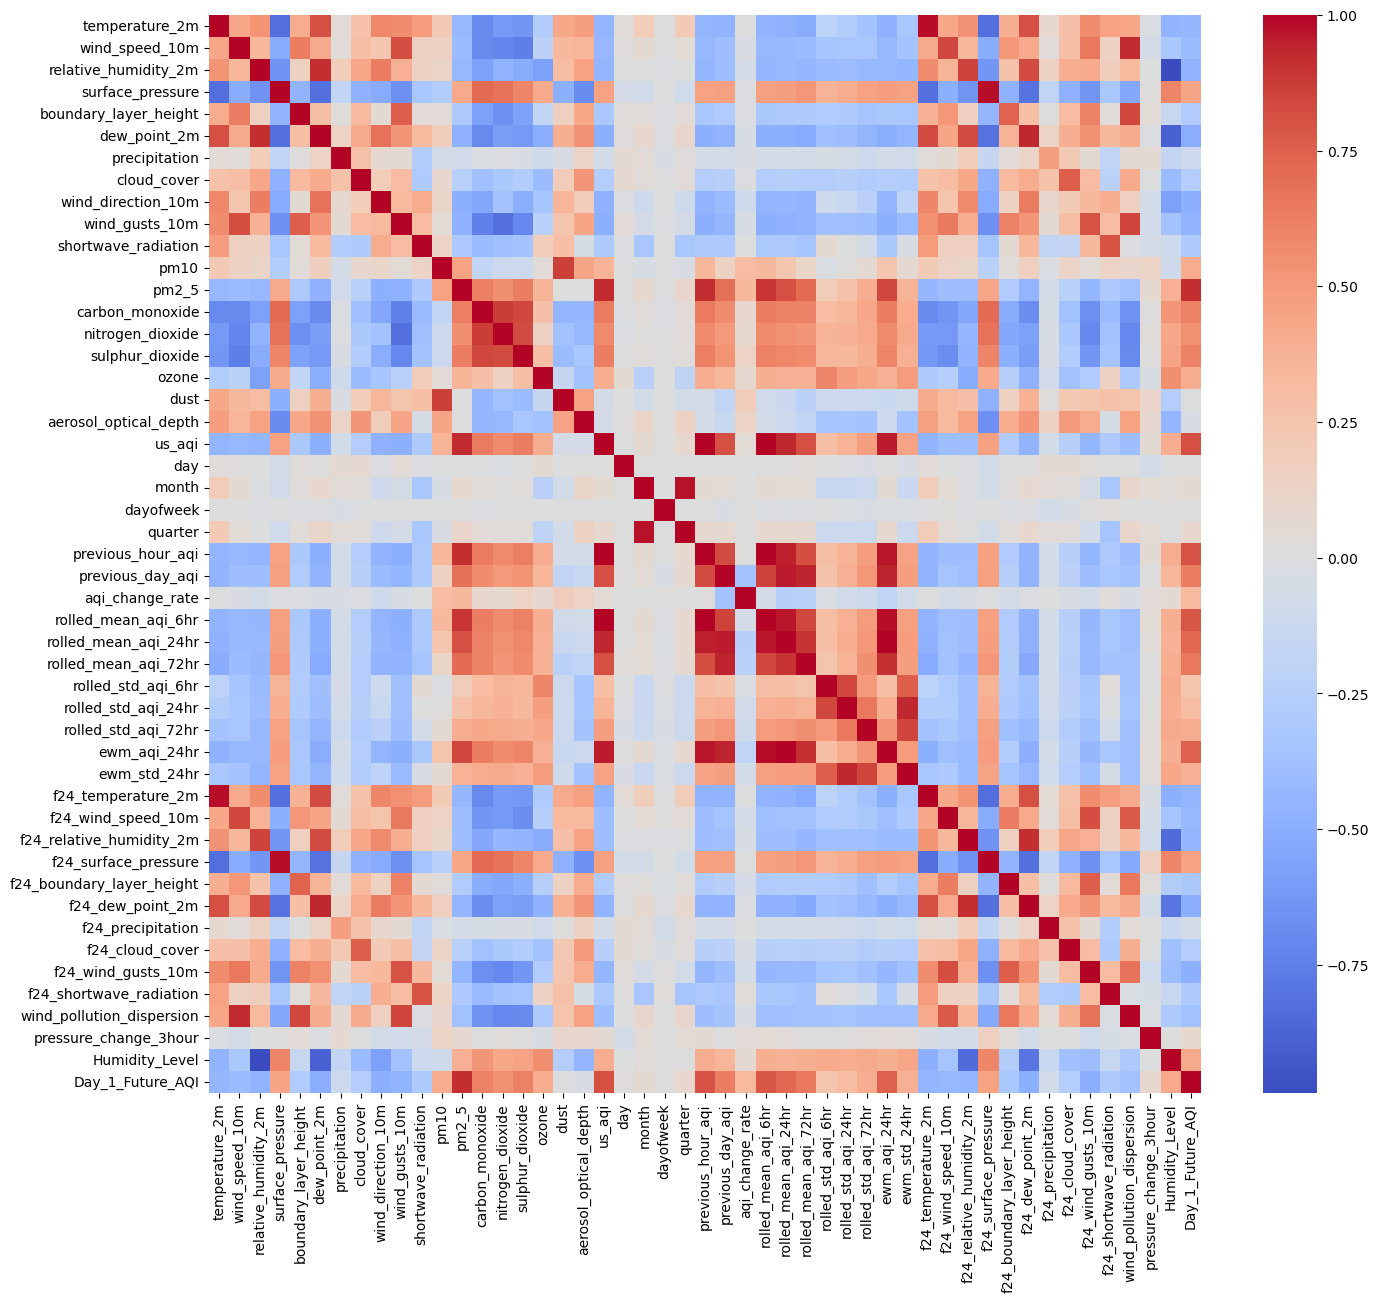

In [16]:
plt.figure(figsize=(16,14))
sns.heatmap(day1.corr(numeric_only=True),cmap="coolwarm")

# Note:
1. The strongest predictors of the target are previous_day_aqi and the rolling mean features (rolled_mean_aqi_6hr, 24hr, 72hr and ewm_aqi_24hr). This validates the feature engineering choices.
2. These lag and rolling features are also highly correlated with each other, since all are smoothed versions of the same AQI series. This multicollinearity does not break tree-based models but it does split feature importance across near-duplicate columns, and it would be a problem for linear regression.
3. Pollutant correlations are structural rather than informative. us_aqi is calculated from pm2_5, pm10, ozone and the other pollutants, so their high correlation only reproduces the AQI formula and reveals nothing new about the data.
4. Calendar features (day, dayofweek, month, quarter) show near-zero linear correlation with AQI. This does not mean they are useless. Pearson correlation measures straight-line relationships and cannot capture a cycle, where high values return periodically. The month bar chart proves the seasonal effect is strong (January 113 vs August 73) even though the correlation is close to zero.
5. Wind speed correlates negatively with AQI, since stronger wind disperses pollutants.
6. previous_hour_aqi still appears in this daily dataset. It was carried over from the hourly pipeline and has no meaning at daily resolution, so it should be dropped or recomputed.
7. The heatmap was originally plotted with cmap="Paired", a qualitative colormap whose colours have no order, which made the values impossible to compare visually. It has been changed to a diverging colormap centred at zero.

# Lets Check Min And Max Of Each Year

In [17]:
day1.resample(rule = 'YE').min()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level,Day_1_Future_AQI,AQI-Category
time,,,,,,,,,,,,,,,,,,,,,
2023-12-31 00:00:00+05:00,19.933333,7.541667,30.458333,998.920833,247.916667,2.812500,0.0,0.0,24.416667,13.683333,...,2.812500,0.0,0.0,13.683333,118.041667,1895.770833,-0.387500,2.745833,59.041667,Moderate
2024-12-31 00:00:00+05:00,16.045833,5.245833,13.833333,991.895833,170.000000,-7.237500,0.0,0.0,32.458333,13.000000,...,-7.237500,0.0,0.0,13.000000,67.041667,1162.854167,-0.562500,2.050000,49.750000,Good
2025-12-31 00:00:00+05:00,17.775000,4.708333,18.333333,994.545833,155.000000,-3.416667,0.0,0.0,25.791667,12.466667,...,-3.416667,0.0,0.0,12.466667,62.875000,692.791667,-0.550000,1.383333,51.833333,Moderate
2026-12-31 00:00:00+05:00,13.616667,5.100000,29.500000,995.445833,178.750000,0.725000,0.0,0.0,44.375000,14.279167,...,0.725000,0.0,0.0,14.279167,114.125000,1226.333333,-0.645833,2.995833,48.333333,Good


In [18]:
day1.resample(rule = 'YE').max()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level,Day_1_Future_AQI,AQI-Category
time,,,,,,,,,,,,,,,,,,,,,
2023-12-31 00:00:00+05:00,30.433333,33.220833,85.333333,1019.058333,967.708333,25.625000,0.500000,99.666667,301.750000,49.770833,...,25.625000,0.500000,99.666667,49.770833,263.541667,30741.333333,0.395833,19.854167,180.083333,Unhealthy
2024-12-31 00:00:00+05:00,33.291667,34.637500,88.833333,1020.166667,1063.750000,27.416667,2.133333,100.000000,320.583333,52.779167,...,27.416667,2.133333,100.000000,52.779167,323.083333,37639.291667,0.700000,29.562500,158.916667,Unhealthy
2025-12-31 00:00:00+05:00,32.608333,21.337500,92.250000,1019.075000,1100.416667,26.937500,2.683333,99.958333,314.875000,50.254167,...,26.937500,2.683333,99.958333,50.254167,310.291667,20511.250000,0.595833,26.225000,160.833333,Unhealthy
2026-12-31 00:00:00+05:00,34.262500,21.504167,84.625000,1021.250000,1102.500000,27.020833,0.608333,98.916667,313.458333,51.370833,...,27.020833,0.608333,98.916667,51.370833,314.041667,20944.979167,0.650000,23.620833,152.416667,Unhealthy


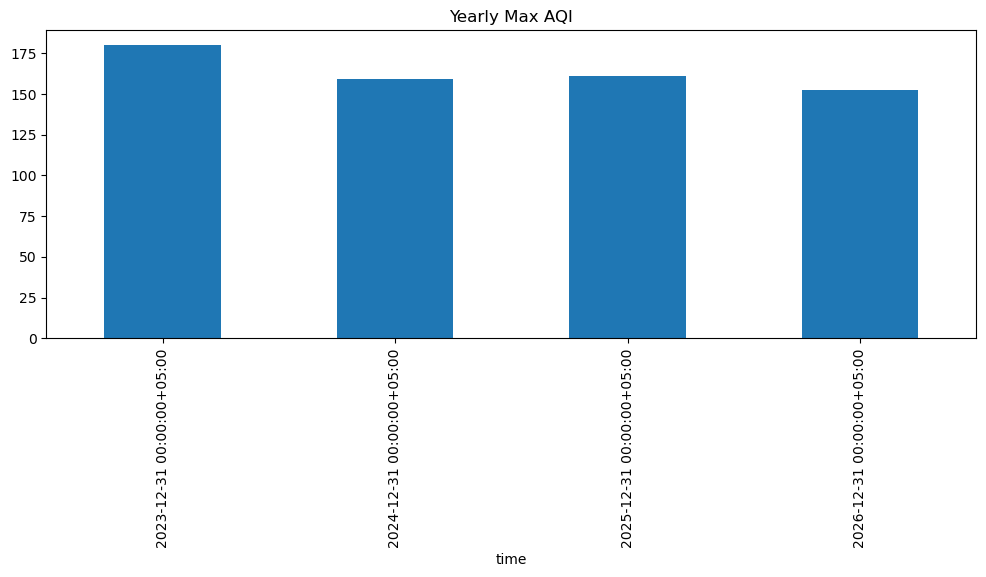

In [19]:
day1["us_aqi"].resample(rule='YE').max().plot(kind = 'bar', figsize=(12,4))
plt.title("Yearly Max AQI")
plt.show()

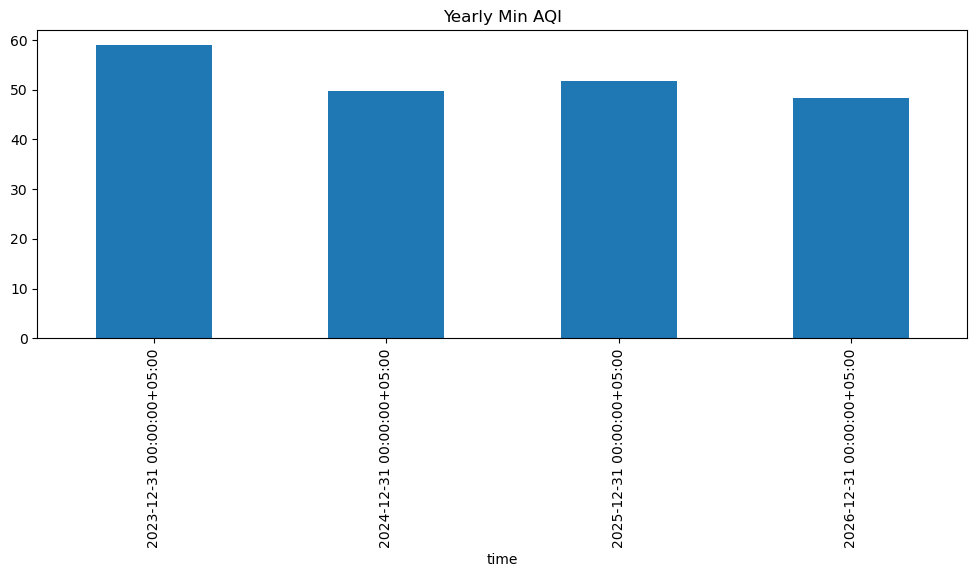

In [20]:
day1["us_aqi"].resample(rule='YE').min().plot(kind = 'bar', figsize=(12,4))
plt.title("Yearly Min AQI")
plt.show()

# Note:
- Both of the charts appear to show decling trend.
- Yearly max AQI are 180 - 2023, 159 - 2024, 161 - 2025, 153 - 2026 as numbers guessed from chart.
- Yearly min AQI are 59 - 2023, 50 - 2024, 52 - 2025, 48 - 2026 as numbers guessed from chart.

# Temporal Patterns

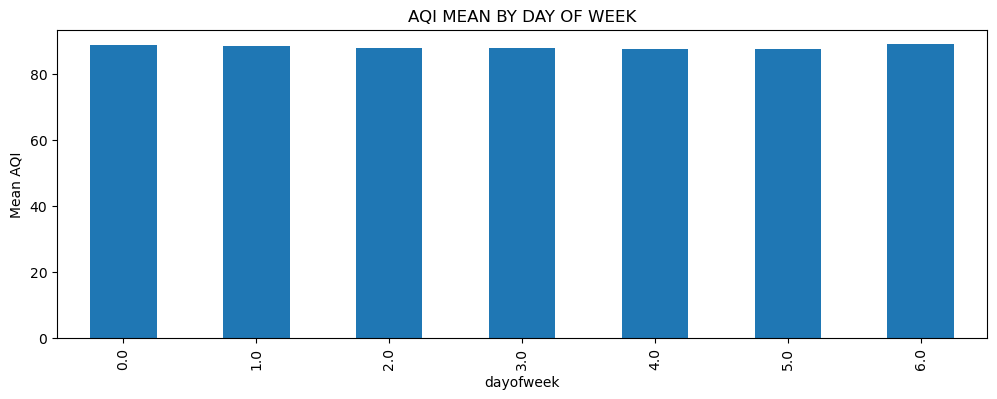

In [22]:
plt.figure(figsize=(12,4))
day1.groupby("dayofweek")["us_aqi"].mean().plot(kind = 'bar')
plt.title("AQI MEAN BY DAY OF WEEK")
plt.ylabel("Mean AQI")
plt.show()

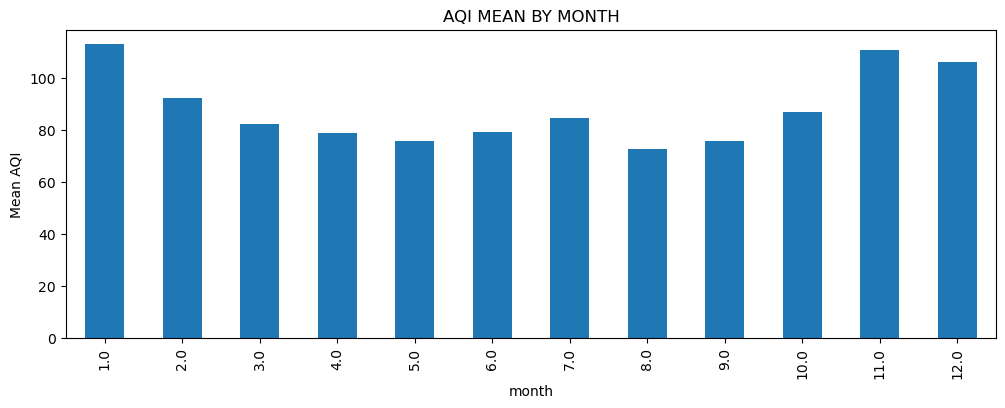

In [23]:
plt.figure(figsize=(12,4))
day1.groupby("month")["us_aqi"].mean().plot(kind = 'bar')
plt.title("AQI MEAN BY MONTH")
plt.ylabel("Mean AQI")
plt.show()

### Note:
1. All 7 days in a week the average is between 87 to 89 AQI which shows no effect.
3. Month seems to be the having strongest impact as January is the highest and August is the lowest.

# Seasonal Decomposition

In [30]:
result = seasonal_decompose(day1['us_aqi'], model='additive', period=365)

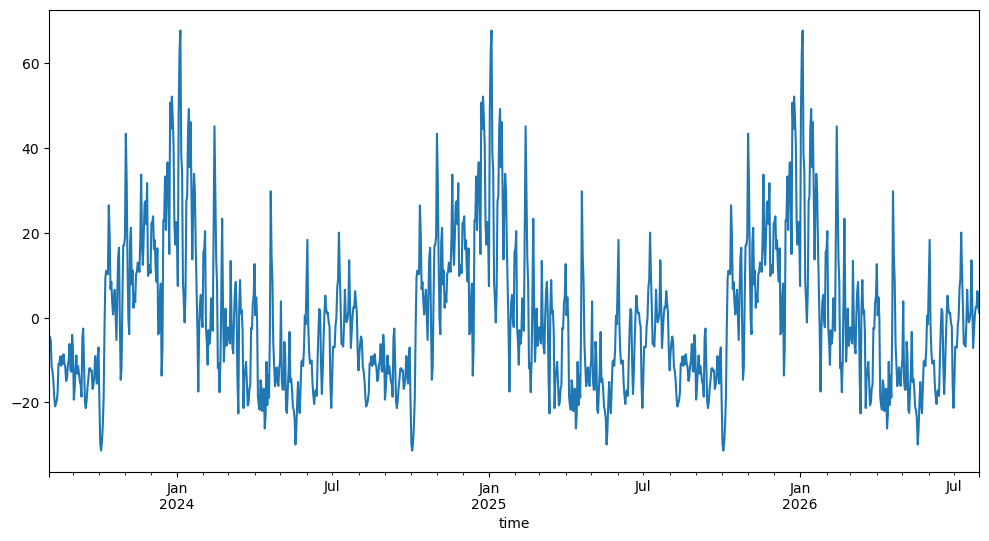

In [34]:
result.seasonal.plot(figsize=(12, 6))
plt.show()

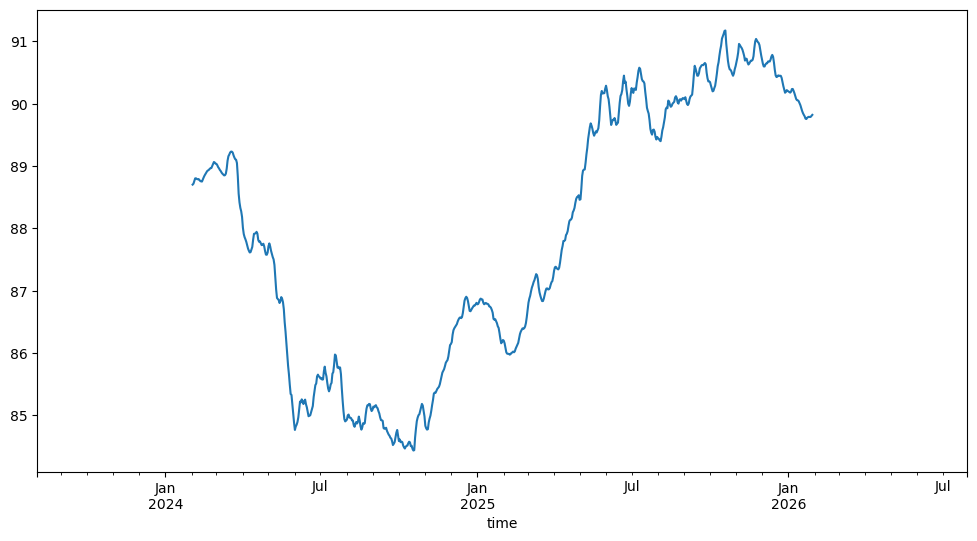

In [35]:
result.trend.plot(figsize=(12, 6))
plt.show()

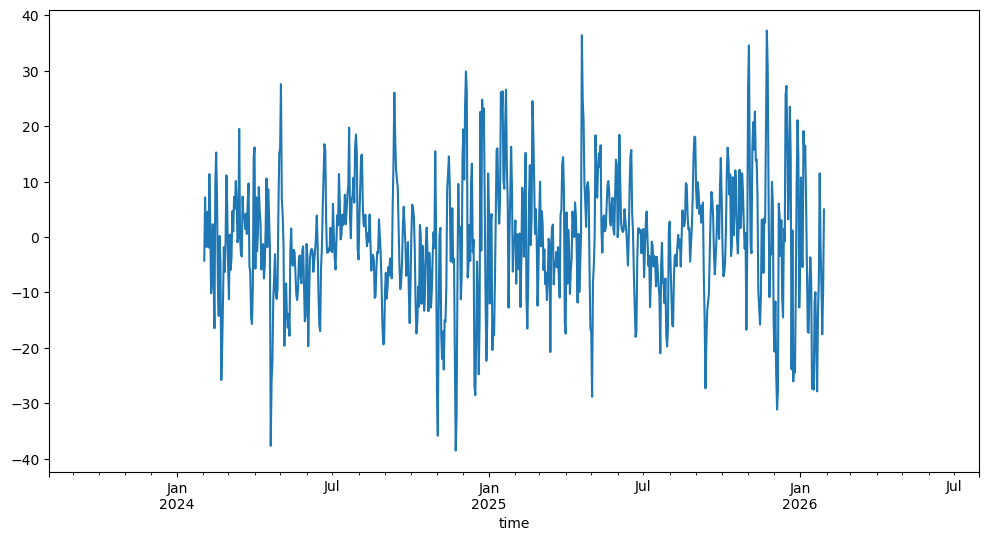

In [36]:
result.resid.plot(figsize=(12, 6))
plt.show()

### Note: The annual cycle is now in the seasonal component and the trend is almost flat, so AQI has not meaningfully changed over three years. The residual is large and more volatile in winter.

# Auto Correlation Function

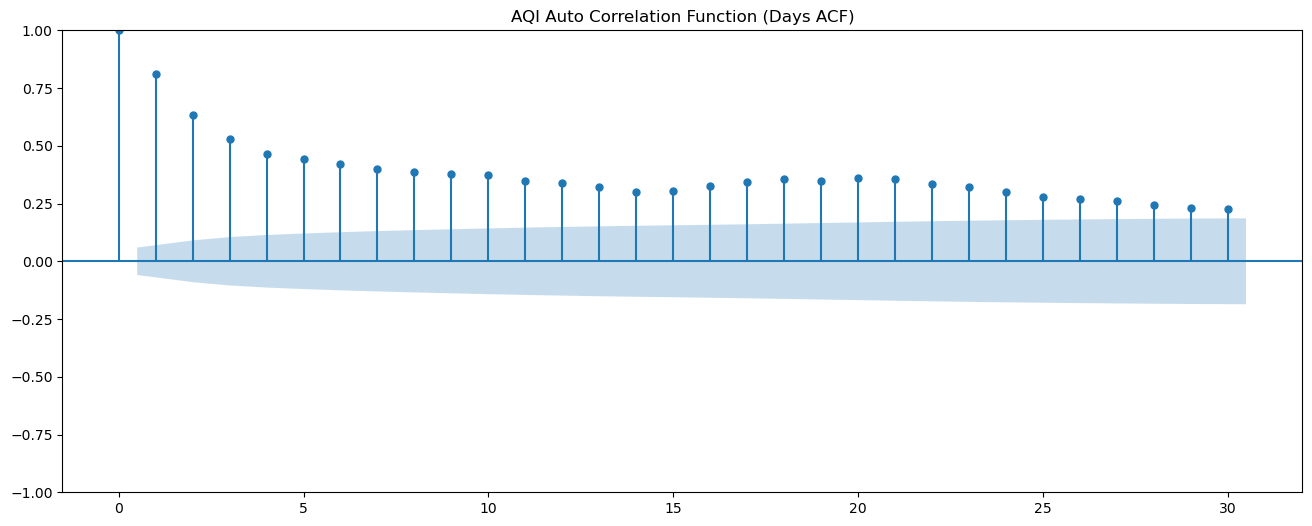

In [28]:
fig, ax = plt.subplots(figsize=(16,6))
plot_acf(day1["us_aqi"], lags=30, ax=ax)
ax.set_title("AQI Auto Correlation Function (Days ACF)")
plt.show()

### Note: 
1. Lag 24 has a correlation almost to 0.81.
2. Lag 48 has a correlation almost to 0.63.
3. Lag 72 has a correlation almost to 0.53.

# Missing Values

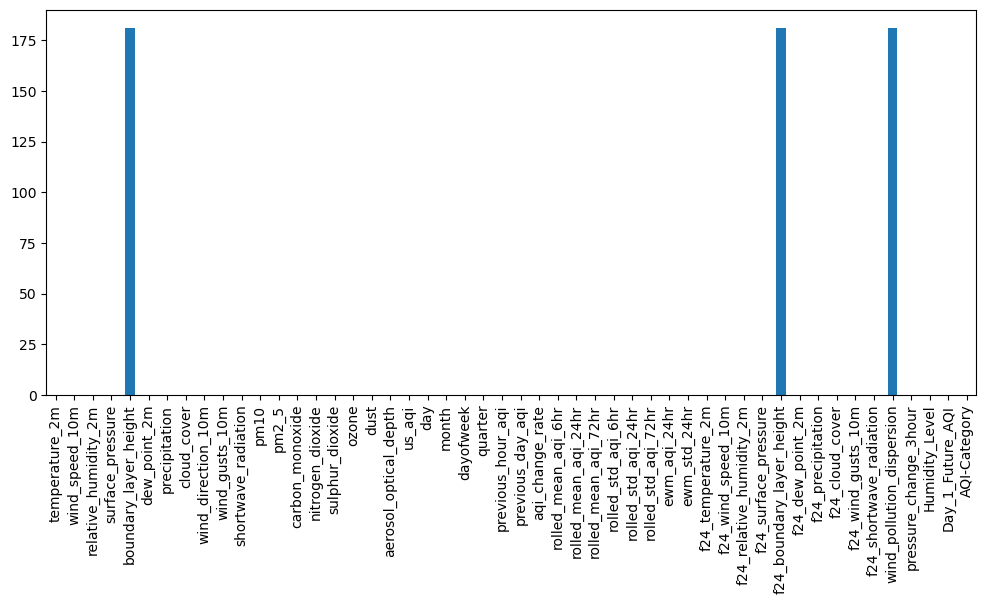

In [29]:
plt.figure(figsize=(12,5))
day1.isnull().sum().plot(kind = 'bar')
plt.show()

### Note: boundary_layer_height, f24_boundary_layer_height, and wind_pollution_dispersion have above 174 null values.